In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from flax import nnx
from probjax.nn import MLP

X = np.linspace(0, 1, 100)[:, None]
Y = 0.8 * X**2 + 0.1 + np.random.normal(0, 0.1, size=X.shape)

def dataset(batch_size):
  while True:
    idx = np.random.choice(len(X), size=batch_size)
    yield X[idx], Y[idx]




In [3]:
model = MLP([1,50,50,1], rngs=nnx.Rngs(0))
nnx.display(model)

2024-10-28 08:20:13.465974: W external/xla/xla/service/gpu/nvptx_compiler.cc:930] The NVIDIA driver's CUDA version is 12.5 which is older than the PTX compiler version 12.6.77. Because the driver is older than the PTX compiler version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [27]:
nnx.initializers.orthogonal()(nnx.Rngs(0).next(), (2,2))

Array([[ 0.911,  0.412],
       [ 0.412, -0.911]], dtype=float32)

In [4]:
def logdenstiy_fn(model):
    y = model(X)
    return -0.5*jnp.sum((Y - y)**2)/0.5**2 - jax.tree_util.tree_reduce(lambda x, y: jnp.sum(y**2) + jnp.sum(y**2), model) # With prior


In [21]:
from probjax.inference.kernels import HMC
from probjax.inference.mcmc import MCMC
import jax

kernel = HMC(logdenstiy_fn)

state = kernel.init(model)
params = kernel.init_params(model, step_size=5e-4)

In [22]:
mcmc = MCMC(kernel, verbose=True)

In [23]:
state = mcmc.run(jax.random.PRNGKey(0), state, 5_000, params)

(-3.0, 3.0)

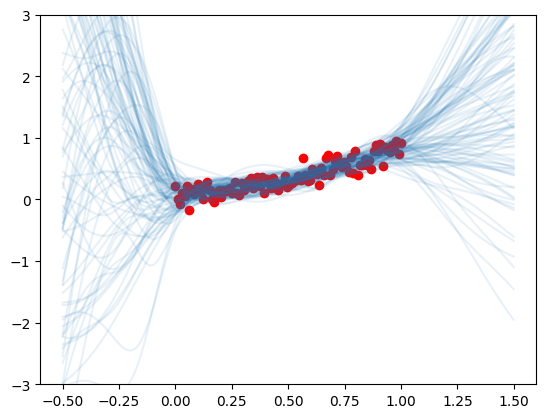

In [24]:
plt.scatter(X, Y, color="red")
for i in range(100):
    state = mcmc.run(jax.random.PRNGKey(i), state, 500, params=params)
    model = state.position
    x = np.linspace(-0.5, 1.5, 100)[:, None]
    plt.plot(x, model(x), color='C0', alpha=0.1)

plt.ylim(-3., 3.)
